# Sono-Modalitätsexperte: Qwen2-VL Fine-Tuning für Ultraschall

**Zwei Nutzungswege:**

- **A) Komplette Reproduktion** (~2 h): Alle Zellen von oben nach unten. Abschnitt 6 überspringen.
- **B) Fertiges Modell testen** (~5 min): Nur Abschnitt 0 (Setup) → Abschnitt 4 (CUBS-Daten) → Abschnitt 6 (Modell laden) → Abschnitt 7 (Evaluation)

## 0. Setup

In [1]:
# Installation benötigte Pakete u.a. Steuerung für Qwen2-VL
!pip install -q transformers accelerate trl peft bitsandbytes
!pip install -q kagglehub qwen-vl-utils datasets
!pip install -q -U torchao

# Installation von Tools für Bild- und Videoverarbeitung
!pip install -q pillow opencv-python



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.9 MB/s eta 0:00:00


## 1. Daten vorbereiten

### 1.1 ROCO Ultraschall (für Phase 1)

Filterung des ROCOv2-Datensatzes nach UMLS-Code `C0041618` (Ultrasonography).
Die Captions werden von Zitationen, Panel-Markern und HTML-Tags bereinigt.

*Nur für Weg A nötig.*

In [ ]:
# ROCOv2: Ultraschallbilder filtern (UMLS-Code C0041618 = Ultrasonography)
# Erster Lauf: ~10 min Download. Bilder werden in /content/roco_us/ abgelegt.
import os, io, json
from datasets import load_dataset
from PIL import Image

ROCO_DIR = '/content/roco_us'

if not os.path.exists(f'{ROCO_DIR}/captions.json'):
    dataset = load_dataset("eltorio/ROCOv2-radiology", split="train", streaming=True)
    US_CUI = 'C0041618'   # UMLS: Ultrasonography

    gefiltert = dataset.filter(lambda x: US_CUI in x.get('cui', []))
    os.makedirs(ROCO_DIR, exist_ok=True)
    captions = {}
    count = 0

    print("Filtere Ultraschallbilder aus ROCOv2...")
    for zeile in gefiltert:
        bild = Image.open(io.BytesIO(zeile['image']['bytes'])).convert('RGB')
        fname = f"us_{count:05d}.jpg"
        bild.save(f'{ROCO_DIR}/{fname}', 'JPEG')
        captions[fname] = zeile['caption']
        count += 1
        if count % 500 == 0:
            print(f"  {count} Bilder...")

    with open(f'{ROCO_DIR}/captions.json', 'w', encoding='utf-8') as f:
        json.dump(captions, f, ensure_ascii=False, indent=2)

    print(f"✓ {count} Ultraschallbilder gespeichert")
else:
    n = len(json.load(open(f'{ROCO_DIR}/captions.json')))
    print(f"✓ {n} Ultraschallbilder bereits vorhanden")

In [ ]:
# Captions bereinigen: Zitationen, Panel-Marker, HTML-Tags entfernen
import json, re, html

captions_raw = json.load(open('/content/roco_us/captions.json'))

def clean_caption(text):
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', '', text)                                  # HTML-Tags
    text = re.sub(r'\[\d+(?:[,\-–]\s*\d+)*\]', '', text)                 # Zitationen [12]
    text = re.sub(r'\(\s*[A-Z][a-z]+(?:\s+et\s+al\.?)?,?\s*\d{4}[a-z]?\s*\)', '', text)
    text = re.sub(r'\b[Ff]ig(?:ure|s|\.)?\s*\.?\s*\d+[A-Za-z]?', '', text)   # Fig. 3
    text = re.sub(r'\b[Tt]able\s*\d+', '', text)
    text = re.sub(r'^\s*[\(\[]?([A-H])[\)\]]?[.:]\s+', '', text)         # Panel-Marker "A:"
    text = re.sub(r'\(\s*\)|\[\s*\]', '', text)
    text = re.sub(r'\s+([.,;:])', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def keep_caption(text):
    return 4 <= len(text.split()) <= 100

captions_clean = {
    f: clean_caption(c) for f, c in captions_raw.items()
    if keep_caption(clean_caption(c))
}

print(f"Roh: {len(captions_raw)} → bereinigt: {len(captions_clean)}")
print(f"Beispiel: {list(captions_clean.values())[0][:100]}")

In [ ]:
def roco_to_conversation(fname, caption):
    """Unsupervised: generischer Prompt + Original-Caption als Ziel."""
    question = "Beschreibe dieses Ultraschallbild."

    return {
        "image": f'/content/roco_us/{fname}',
        "conversations": [
            {"role": "user", "content": question},
            {"role": "assistant", "content": caption}
        ],
        "source": "ROCO",
        "group_id": f"ROCO_{fname}"
    }

roco_records = [roco_to_conversation(f, c) for f, c in captions_clean.items()]
print(f"ROCO-Records: {len(roco_records)}")
print("\nBeispiel:", json.dumps(roco_records[0], indent=2, ensure_ascii=False)[:400])

ROCO-Records: 8136

Beispiel: {
  "image": "/content/roco_us/us_00000.jpg",
  "conversations": [
    {
      "role": "user",
      "content": "Beschreibe dieses Ultraschallbild."
    },
    {
      "role": "assistant",
      "content": "Acquired renal cysts in end-stage renal failure: 16-year-old girl with Alport syndrome and peritoneal dialysis from the age of 2 years"
    }
  ],
  "source": "ROCO",
  "group_id": "ROCO_us_000


In [ ]:
import random

random.seed(42)
random.shuffle(roco_records)

# 90/10 Split
split_idx = int(len(roco_records) * 0.9)
roco_train = roco_records[:split_idx]
roco_val = roco_records[split_idx:]

print(f"Unsupervised Training:   {len(roco_train)}")
print(f"Unsupervised Validation: {len(roco_val)}")

with open('/content/roco_train.json', 'w', encoding='utf-8') as f:
    json.dump(roco_train, f, ensure_ascii=False, indent=2)
with open('/content/roco_val.json', 'w', encoding='utf-8') as f:
    json.dump(roco_val, f, ensure_ascii=False, indent=2)

print("ROCO-Splits gespeichert")

Unsupervised Training:   7322
Unsupervised Validation: 814
ROCO-Splits gespeichert


### 1.2 CUBS Carotis (für Phase 2)
*Für beide Wege nötig.*

In [ ]:
# CUBS herunterladen und entpacken
import os

if not os.path.exists('/content/cubs/extracted/DATASET_CUBS_tech/images'):
    !wget -q -O cubs.zip "https://data.mendeley.com/public-api/zip/m7ndn58sv6/download/1"
    !unzip -o -q cubs.zip -d /content/cubs
    !unzip -o -q /content/cubs/m7ndn58sv6-1/DATASET_CUBS_tech.zip -d /content/cubs/extracted
    print("CUBS heruntergeladen und entpackt")
else:
    print("CUBS bereits vorhanden")

dataset_root = '/content/cubs/extracted/DATASET_CUBS_tech'
manual_a1_path = os.path.join(dataset_root, 'LIMA-Profiles', 'Manual-A1')
print("Inhalt:", os.listdir(dataset_root))

In [9]:
import numpy as np

def load_profile(filepath):
    """Liest eine LI/MA-Datei und gibt die Koordinaten als Array zurück."""
    points = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                x, y = map(float, line.split())
                points.append((x, y))
    return np.array(points)

def compute_imt(li_path, ma_path, cf_path):
    """Berechnet die durchschnittliche IMT in mm."""
    li = load_profile(li_path)
    ma = load_profile(ma_path)

    with open(cf_path, 'r') as f:
        cf = float(f.read().strip())

    # Gemeinsamen x-Bereich finden, da LI/MA unterschiedlich viele Punkte haben können
    n = min(len(li), len(ma))
    li, ma = li[:n], ma[:n]

    # Vertikaler Abstand (y-Differenz) zwischen den beiden Linien an jedem Punkt
    distances_px = np.abs(ma[:, 1] - li[:, 1])
    mean_imt_mm = distances_px.mean() * cf

    return mean_imt_mm

In [10]:
def compute_imt_v2(li_path, ma_path, cf_path):
    li = load_profile(li_path)
    ma = load_profile(ma_path)

    with open(cf_path, 'r') as f:
        cf = float(f.read().strip())

    # Gemeinsamer x-Bereich: wo überlappen sich beide Linien?
    x_min = max(li[:, 0].min(), ma[:, 0].min())
    x_max = min(li[:, 0].max(), ma[:, 0].max())

    # 500 gleichmäßig verteilte x-Stützpunkte im überlappenden Bereich
    x_common = np.linspace(x_min, x_max, 500)

    # np.interp: schätzt y-Werte an den x_common-Stellen,
    # indem zwischen den echten Datenpunkten linear interpoliert wird
    li_y_interp = np.interp(x_common, li[:, 0], li[:, 1])
    ma_y_interp = np.interp(x_common, ma[:, 0], ma[:, 1])

    distances_px = np.abs(ma_y_interp - li_y_interp)
    mean_imt_mm = distances_px.mean() * cf

    return mean_imt_mm

In [11]:
import pandas as pd
import os

results = []

# Alle LI-Dateien durchgehen, um die Liste der Bild-IDs zu bekommen
li_files = [f for f in os.listdir(manual_a1_path) if f.endswith('-LI.txt')]

for li_file in li_files:
    # Bild-ID aus dem Dateinamen extrahieren, z.B. "tech_033-LI.txt" -> "tech_033"
    image_id = li_file.replace('-LI.txt', '')

    li_path = os.path.join(manual_a1_path, f'{image_id}-LI.txt')
    ma_path = os.path.join(manual_a1_path, f'{image_id}-MA.txt')
    cf_path = os.path.join(dataset_root, 'CF', f'{image_id}_CF.txt')
    image_path = os.path.join(dataset_root, 'images', f'{image_id}.tiff')

    # Überspringen, falls eine der Dateien fehlt
    if not (os.path.exists(ma_path) and os.path.exists(cf_path) and os.path.exists(image_path)):
        print(f"Überspringe {image_id}: Datei fehlt")
        continue

    try:
        imt_mm = compute_imt_v2(li_path, ma_path, cf_path)
        results.append({
            'image_id': image_id,
            'image_path': image_path,
            'imt_mm': imt_mm
        })
    except Exception as e:
        print(f"Fehler bei {image_id}: {e}")

df = pd.DataFrame(results)
print(f"Erfolgreich verarbeitet: {len(df)} von {len(li_files)} Bildern")
print(df.head())
print(df['imt_mm'].describe())

Erfolgreich verarbeitet: 500 von 500 Bildern
   image_id                                         image_path    imt_mm
0  tech_344  /content/cubs/extracted/DATASET_CUBS_tech/imag...  0.855658
1  tech_061  /content/cubs/extracted/DATASET_CUBS_tech/imag...  0.622192
2  tech_289  /content/cubs/extracted/DATASET_CUBS_tech/imag...  0.994826
3  tech_396  /content/cubs/extracted/DATASET_CUBS_tech/imag...  0.740759
4  tech_074  /content/cubs/extracted/DATASET_CUBS_tech/imag...  0.899107
count    500.000000
mean       0.865326
std        0.259856
min        0.269791
25%        0.682613
50%        0.848078
75%        1.024047
max        2.071835
Name: imt_mm, dtype: float64


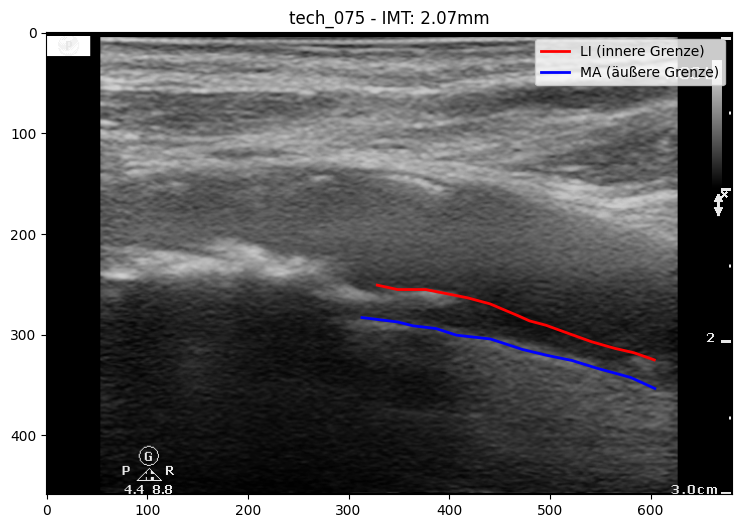

In [23]:
import matplotlib.pyplot as plt
from PIL import Image

image_id = 'tech_075'

li_path = os.path.join(manual_a1_path, f'{image_id}-LI.txt')
ma_path = os.path.join(manual_a1_path, f'{image_id}-MA.txt')
image_path = os.path.join(dataset_root, 'images', f'{image_id}.tiff')

li = load_profile(li_path)
ma = load_profile(ma_path)
img = Image.open(image_path)

plt.figure(figsize=(12, 6))
plt.imshow(img, cmap='gray')
plt.plot(li[:, 0], li[:, 1], 'r-', linewidth=2, label='LI (innere Grenze)')
plt.plot(ma[:, 0], ma[:, 1], 'b-', linewidth=2, label='MA (äußere Grenze)')
plt.legend()
plt.title(f'{image_id} - IMT: 2.07mm')
plt.show()

In [12]:
def imt_to_text(imt_mm):
    """Wandelt einen IMT-Wert in einen englischen Befundtext um."""
    if imt_mm < 0.9:
        category = "within normal range"
    elif imt_mm < 1.2:
        category = "borderline elevated"
    else:
        category = "markedly elevated, consistent with advanced atherosclerosis"

    return f"Intima-media thickness measures {imt_mm:.2f} mm, {category}."

df['befund_text'] = df['imt_mm'].apply(imt_to_text)
print(df[['image_id', 'imt_mm', 'befund_text']].head())

   image_id    imt_mm                                        befund_text
0  tech_344  0.855658  Intima-media thickness measures 0.86 mm, withi...
1  tech_061  0.622192  Intima-media thickness measures 0.62 mm, withi...
2  tech_289  0.994826  Intima-media thickness measures 0.99 mm, borde...
3  tech_396  0.740759  Intima-media thickness measures 0.74 mm, withi...
4  tech_074  0.899107  Intima-media thickness measures 0.90 mm, withi...


In [13]:
def cubs_to_conversation(row):
    """Baut das Trainingsformat: Bild + Frage + Antwort (Trainingstexte auf Englisch)."""
    question = "Analyze this carotid ultrasound image in longitudinal view. What is the intima-media thickness?"
    answer = f"Longitudinal B-mode ultrasound of the common carotid artery. {row['befund_text']}"

    return {
        "image": row['image_path'],
        "conversations": [
            {"role": "user", "content": question},
            {"role": "assistant", "content": answer}
        ],
        "source": "CUBS",
        "group_id": f"CUBS_{row['image_id']}"
    }

cubs_records = [cubs_to_conversation(row) for _, row in df.iterrows()]
print(f"CUBS-Einträge: {len(cubs_records)}")
print(cubs_records[0])

CUBS-Einträge: 500
{'image': '/content/cubs/extracted/DATASET_CUBS_tech/images/tech_344.tiff', 'conversations': [{'role': 'user', 'content': 'Analyze this carotid ultrasound image in longitudinal view. What is the intima-media thickness?'}, {'role': 'assistant', 'content': 'Longitudinal B-mode ultrasound of the common carotid artery. Intima-media thickness measures 0.86 mm, within normal range.'}], 'source': 'CUBS', 'group_id': 'CUBS_tech_344'}


In [14]:
import random, json
from collections import defaultdict

all_records = cubs_records
print(f"Gesamt: {len(all_records)} CUBS-Bilder")

# Gruppierter Split (jedes Bild = eigene Gruppe bei CUBS)
groups = defaultdict(list)
for r in all_records:
    groups[r['group_id']].append(r)

group_ids = list(groups.keys())
random.seed(42)
random.shuffle(group_ids)

train_end = int(len(group_ids) * 0.8)
val_end = int(len(group_ids) * 0.9)

train_records = [r for gid in group_ids[:train_end] for r in groups[gid]]
val_records   = [r for gid in group_ids[train_end:val_end] for r in groups[gid]]
test_records  = [r for gid in group_ids[val_end:] for r in groups[gid]]

print(f"Train: {len(train_records)} | Val: {len(val_records)} | Test: {len(test_records)}")

for name, data in [('train', train_records), ('val', val_records), ('test', test_records)]:
    with open(f'/content/{name}_data.json', 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

print("Splits gespeichert")

Gesamt: 500 CUBS-Bilder
Train: 400 | Val: 50 | Test: 50
Splits gespeichert


## 2. Modell + LoRA + Augmentation + Collator
*Nur für Weg A nötig.*

In [2]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from peft import PeftModel
from google.colab import userdata

model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype=torch.bfloat16, device_map="auto")
processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", min_pixels=256*28*28, max_pixels=1280*28*28)

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
!rm -rf /content/repo
!git clone -q https://{GITHUB_TOKEN}@github.com/friedefleu/qwen2vl-carotid-ultrasound.git /content/repo

model = PeftModel.from_pretrained(model, "/content/repo/model/unsupervised_adapter", is_trainable=True)
model.print_trainable_parameters()
print("Phase-1-Modell (unsupervised) geladen")

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

trainable params: 4,358,144 || all params: 2,213,343,744 || trainable%: 0.1969
Phase-1-Modell (unsupervised) geladen


In [21]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import numpy as np
import json, os

def add_speckle_noise(img, intensity=0.08):
    """Simuliert Ultraschall-Speckle (multiplikatives Rauschen/
    Physikalisch authentisch)"""
    arr = np.array(img).astype(np.float32) / 255.0
    noise = np.random.normal(1.0, intensity, arr.shape)
    noisy = np.clip(arr * noise, 0, 1) * 255
    return Image.fromarray(noisy.astype(np.uint8))

# Modalitäts-authentische Augmentation für Ultraschall.
# Bewusst ohne Rotation/Affine: würde die Wandgeometrie und damit die
# Ziel-Variable IMT verfälschen. Ohne vertikalen Flip: unphysiologisch
ultrasound_augment = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Lambda(lambda img: add_speckle_noise(img, 0.08)),
])

class UltrasoundDataset(Dataset):
    def __init__(self, json_path, processor, augment=False):
        with open(json_path, 'r', encoding='utf-8') as f:
            self.records = json.load(f)
        self.processor = processor
        self.augment = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        image = Image.open(record['image']).convert('RGB')

        if self.augment:
            image = ultrasound_augment(image)

        messages = [
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text", "text": record['conversations'][0]['content']}
            ]},
            {"role": "assistant", "content": [
                {"type": "text", "text": record['conversations'][1]['content']}
            ]}
        ]
        return {"messages": messages, "image": image}

print("UltrasoundDataset mit Ultraschall-Augmentation definiert")

# ROCO-Datasets (Phase 1)
if os.path.exists('/content/roco_train.json'):
    roco_train_ds = UltrasoundDataset('/content/roco_train.json', processor, augment=False)
    roco_val_ds   = UltrasoundDataset('/content/roco_val.json', processor, augment=False)
    print(f"   ROCO: Train {len(roco_train_ds)} | Val {len(roco_val_ds)}")
else:
    print("   (ROCO-Splits nicht vorhanden – Phase 1 übersprungen)")

# CUBS-Datasets (Phase 2) MIT Augmentation
if os.path.exists('/content/train_data.json'):
    cubs_train_ds = UltrasoundDataset('/content/train_data.json', processor, augment=True)   # ← AUGMENTIERT
    cubs_val_ds   = UltrasoundDataset('/content/val_data.json', processor, augment=False)
    cubs_test_ds  = UltrasoundDataset('/content/test_data.json', processor, augment=False)
    print(f"   CUBS: Train {len(cubs_train_ds)} (augmentiert) | Val {len(cubs_val_ds)} | Test {len(cubs_test_ds)}")
else:
    print("   (CUBS-Splits noch nicht erstellt)")

UltrasoundDataset mit Ultraschall-Augmentation definiert
   (ROCO-Splits nicht vorhanden – Phase 1 übersprungen)
   CUBS: Train 400 (augmentiert) | Val 50 | Test 50


In [3]:
from qwen_vl_utils import process_vision_info
import torch

def collate_fn(batch):
    messages_list = [item['messages'] for item in batch]
    images_list = [item['image'] for item in batch]

    texts = [
        processor.apply_chat_template(m, tokenize=False, add_generation_prompt=False)
        for m in messages_list
    ]

    batch_inputs = processor(
        text=texts, images=images_list, return_tensors="pt", padding=True
    )

    labels = batch_inputs['input_ids'].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    image_token_id = processor.tokenizer.convert_tokens_to_ids('<|image_pad|>')
    labels[labels == image_token_id] = -100

    for i in range(labels.shape[0]):
        ids = batch_inputs['input_ids'][i].tolist()
        try:
            assistant_pos = len(ids) - 1 - ids[::-1].index(77091)
            labels[i, :assistant_pos + 2] = -100
        except ValueError:
            pass

    batch_inputs['labels'] = labels
    return batch_inputs

print("Collator bereit")

Collator bereit


In [27]:
import torch

# GPU
print("CUDA verfügbar:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

# Wo liegt das Modell gerade?
for name, param in model.named_parameters():
    print(f"Modell liegt auf: {param.device}")
    break

# Aktueller VRAM-Verbrauch
print(f"VRAM belegt: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")
print(f"VRAM gesamt: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

CUDA verfügbar: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Modell liegt auf: cuda:0
VRAM belegt: 8.2 GB
VRAM gesamt: 95.0 GB


## 3. Phase 1: Unsupervised Fine-Tuning (ROCO)

Modalitäts-Adaption: Das Modell lernt Fachsprache und Report-Stil der Ultraschall-Radiologie.

*Nur für Weg A. Dauer: ~1 h*

In [ ]:
from trl import SFTTrainer, SFTConfig
import math

baseline_args = SFTConfig(
    output_dir="/content/tmp_baseline",
    per_device_eval_batch_size=1,
    fp16=False, bf16=False,
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    report_to="none"
)

baseline_trainer = SFTTrainer(
    model=model,
    args=baseline_args,
    train_dataset=roco_train_ds,
    eval_dataset=roco_val_ds,
    data_collator=collate_fn,
)

print("Messe Baseline (Basismodell OHNE Fine-Tuning)...")
baseline_results = baseline_trainer.evaluate()

baseline_loss = baseline_results['eval_loss']
print(f"\n>>> BASELINE Loss (vor Training): {baseline_loss:.4f}")
print(f">>> BASELINE Perplexity: {math.exp(baseline_loss):.2f}")

Messe Baseline (Basismodell OHNE Fine-Tuning)...


Training Loss,Validation Loss,Step,Entropy,Num Tokens,Mean Token Accuracy
No log,2.925129,0,1.958940,0.000000,0.486750



>>> BASELINE Loss (vor Training): 2.9251
>>> BASELINE Perplexity: 18.64


In [ ]:
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback

training_args = SFTConfig(
    output_dir="/content/qwen2vl_ultrasound_unsup",
    num_train_epochs=2,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_ratio=0.05,
    fp16=False, bf16=False,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    report_to="none"
)

trainer_unsup = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=roco_train_ds,
    eval_dataset=roco_val_ds,
    data_collator=collate_fn,
)

print("Starte UNSUPERVISED Fine-Tuning auf ROCO-Ultraschall...")
print(f"(Baseline war: Loss {baseline_loss:.4f}, Perplexity {math.exp(baseline_loss):.2f})\n")

stats = trainer_unsup.train()

print(f"\nUnsupervised Training abgeschlossen!")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Starte UNSUPERVISED Fine-Tuning auf ROCO-Ultraschall...
(Baseline war: Loss 2.9251, Perplexity 18.64)



Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,2.023432,2.152161,2.190003,3724049.000000,0.556020
2,2.033156,2.134889,2.135732,7448098.000000,0.560052



Unsupervised Training abgeschlossen!


In [ ]:
import math, os, shutil

# Neue Metriken nach unsupervised Training
final_results = trainer_unsup.evaluate()
final_loss = final_results['eval_loss']

print("="*60)
print("UNSUPERVISED FINE-TUNING – ERGEBNIS")
print("="*60)
print(f"Loss:       {baseline_loss:.4f} → {final_loss:.4f}")
print(f"Perplexity: {math.exp(baseline_loss):.2f} → {math.exp(final_loss):.2f}")
verbesserung = (baseline_loss - final_loss) / baseline_loss * 100
print(f"Verbesserung: {verbesserung:.1f}%")

# Adapter lokal speichern
os.makedirs('/content/model_unsupervised', exist_ok=True)
model.save_pretrained('/content/model_unsupervised')
processor.save_pretrained('/content/model_unsupervised')
print("\n Unsupervised-Modell gespeichert")

Training Loss,Validation Loss,Epoch,Entropy,Num Tokens,Mean Token Accuracy
2.033156,2.134889,2,2.135732,7448098.000000,0.560052


UNSUPERVISED FINE-TUNING – ERGEBNIS
Loss:       2.9251 → 2.1349
Perplexity: 18.64 → 8.46
Verbesserung: 27.0%

 Unsupervised-Modell gespeichert


In [ ]:
from qwen_vl_utils import process_vision_info
from PIL import Image
import torch, json, random

def beschreibe_bild(image_path):
    image = Image.open(image_path).convert('RGB')
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": "Beschreibe dieses Ultraschallbild."}
    ]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=80, do_sample=False)
    return processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0]

# 3 Beispiele aus dem Val-Set
val_data = json.load(open('/content/roco_val.json'))
random.seed(42)
beispiele = random.sample(val_data, 3)

print("\n=== Qualitative Beispiele (nach unsupervised Training) ===")
for i, sample in enumerate(beispiele, 1):
    gen = beschreibe_bild(sample['image'])
    print(f"\nBeispiel {i}:")
    print(f"  Echte Caption: {sample['conversations'][1]['content'][:120]}")
    print(f"  Modell sagt:   {gen[:120]}")


=== Qualitative Beispiele (nach unsupervised Training) ===

Beispiel 1:
  Echte Caption: Contrast-enhanced sonography after intravenous injection of 2.4 mL Sono-Vue® in the arterial phase: the hyperechogenic s
  Modell sagt:   Ultrasound image of the fetal heart. The fetal heart is seen in the right ventricle (white arrows) and the left ventricl

Beispiel 2:
  Echte Caption: Transverse high-resolution USG grey scale image (7–11 MHz) image (A) of medial aspect of distal foot showing hypoechoic 
  Modell sagt:   Ultrasound image of the right foot showing a large, heterogeneous, hypoechoic mass (arrow) with a well-defined margin.

Beispiel 3:
  Echte Caption: Transesophageal echocardiographic view demonstrating transverse and posteroanterior measurements of left ventricle in en
  Modell sagt:   Transesophageal echocardiography showing the left atrial mass.


In [ ]:
import os, shutil
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USER = "friedefleu"
GITHUB_REPO = "qwen2vl-carotid-ultrasound"
EMAIL = "297671624+friedefleu@users.noreply.github.com"
NAME = "friedefleu"

!rm -rf /content/repo
!git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git /content/repo

!git -C /content/repo config user.email "{EMAIL}"
!git -C /content/repo config user.name "{NAME}"

# Unsupervised-Modell ins Repo
os.makedirs('/content/repo/model/unsupervised_adapter', exist_ok=True)
model.save_pretrained('/content/repo/model/unsupervised_adapter')
processor.save_pretrained('/content/repo/model/unsupervised_adapter')

# Metriken dokumentieren
metrics = {
    "phase": "unsupervised (ROCO ultrasound)",
    "train_images": len(roco_train_ds),
    "val_images": len(roco_val_ds),
    "baseline_loss": round(baseline_loss, 4),
    "final_loss": round(final_loss, 4),
    "baseline_perplexity": round(math.exp(baseline_loss), 2),
    "final_perplexity": round(math.exp(final_loss), 2),
}
with open('/content/repo/model/unsupervised_adapter/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

!git -C /content/repo add .
!git -C /content/repo commit -m "Add unsupervised ultrasound modality adapter (ROCO)"
!git -C /content/repo push https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git

print("Unsupervised-Modell auf GitHub!")

Cloning into '/content/repo'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 74 (delta 0), reused 0 (delta 0), pack-reused 73 (from 1)
Receiving objects: 100% (74/74), 193.93 MiB | 33.34 MiB/s, done.
Resolving deltas: 100% (26/26), done.
[main 08c8c16] Add unsupervised ultrasound modality adapter (ROCO)
 8 files changed, 757735 insertions(+)
 create mode 100644 model/unsupervised_adapter/README.md
 create mode 100644 model/unsupervised_adapter/adapter_config.json
 create mode 100644 model/unsupervised_adapter/adapter_model.safetensors
 create mode 100644 model/unsupervised_adapter/chat_template.jinja
 create mode 100644 model/unsupervised_adapter/metrics.json
 create mode 100644 model/unsupervised_adapter/processor_config.json
 create mode 100644 model/unsupervised_adapter/tokenizer.json
 create mode 100644 model/unsupervised_adapter/tokenizer_config.json
Enumerating objects: 14, done.
Counting objects: 100% (14/14), done.
Delta compr

## 4. Phase 2: Supervised Fine-Tuning (CUBS)

Baut auf dem Modell aus Phase 1 auf.
Beurteilung der Intima-Media-Dicke (normal / grenzwertig / erhöht).

*Nur für Weg A.*

In [16]:
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback

print(f"CUBS Train: {len(cubs_train_ds)} | Val: {len(cubs_val_ds)} | Test: {len(cubs_test_ds)}")

training_args = SFTConfig(
    output_dir="/content/qwen2vl_carotid",
    num_train_epochs=10,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.05,
    fp16=False,
    bf16=False,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=10,
    remove_unused_columns=False,
    dataloader_pin_memory=False,
    report_to="none"
)

trainer = SFTTrainer(
    model=model,                    #  Modell aus Phase 1 (unsupervised)
    args=training_args,
    train_dataset=cubs_train_ds,
    eval_dataset=cubs_val_ds,
    data_collator=collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Phase-2-Trainer bereit (baut auf unsupervised Modell auf)")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


CUBS Train: 400 | Val: 50 | Test: 50
Phase-2-Trainer bereit (baut auf unsupervised Modell auf)


In [22]:
import torch

# VRAM vor Training
print(f"VRAM vor Training: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")

# Training starten
trainer_stats = trainer.train()

# Ergebnisse
print(f"\n Training abgeschlossen!")
print(f"Training Loss: {trainer_stats.training_loss:.4f}")
print(f"VRAM nach Training: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")

VRAM vor Training: 4.2 GB


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.143392,0.146920,0.143309,2455150.000000,0.938065
2,0.141031,0.143431,0.146315,2700665.000000,0.939611
3,0.139711,0.142803,0.140978,2946180.000000,0.937834
4,0.145193,0.143885,0.139028,3191695.000000,0.937814
5,0.137310,0.142800,0.136417,3437210.000000,0.940585
6,0.134006,0.144468,0.137091,3682725.000000,0.939335
7,0.134405,0.145536,0.133148,3928240.000000,0.939125
8,0.132277,0.148643,0.134552,4173755.000000,0.943105



 Training abgeschlossen!
Training Loss: 0.1364
VRAM nach Training: 4.2 GB


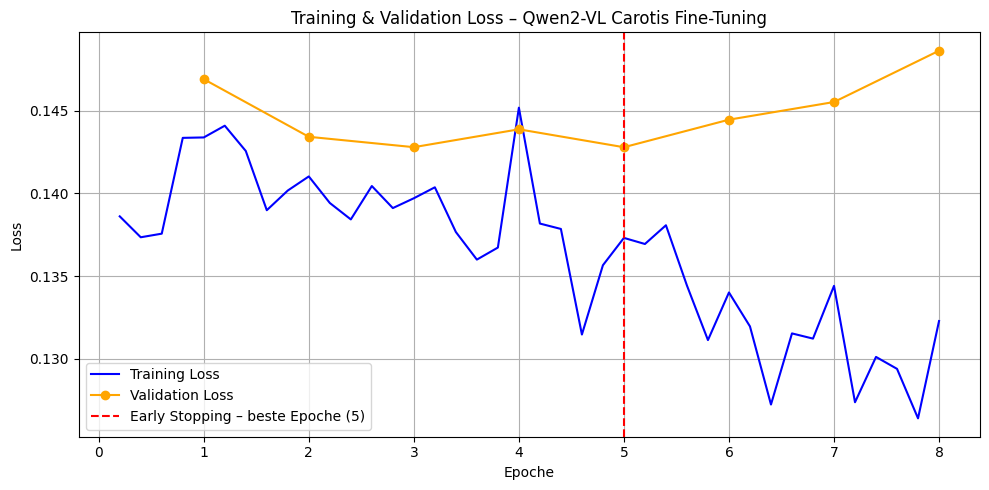

Grafik gespeichert als loss_curve.png


In [23]:
import matplotlib.pyplot as plt
import json

# Loss-Historie aus dem Trainer extrahieren
history = trainer.state.log_history

train_loss = [(x['epoch'], x['loss']) for x in history if 'loss' in x and 'eval_loss' not in x]
val_loss = [(x['epoch'], x['eval_loss']) for x in history if 'eval_loss' in x]

train_epochs = [x[0] for x in train_loss]
train_values = [x[1] for x in train_loss]
val_epochs = [x[0] for x in val_loss]
val_values = [x[1] for x in val_loss]

plt.figure(figsize=(10, 5))
plt.plot(train_epochs, train_values, label='Training Loss', color='blue')
plt.plot(val_epochs, val_values, label='Validation Loss', color='orange', marker='o')

# Beste Epoche markieren (wo Early Stopping das beste Modell gespeichert hat)
best_epoch = val_epochs[val_values.index(min(val_values))]
plt.axvline(x=best_epoch, color='red', linestyle='--',
            label=f'Early Stopping – beste Epoche ({best_epoch:.0f})')

plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.title('Training & Validation Loss – Qwen2-VL Carotis Fine-Tuning')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/loss_curve.png', dpi=150)
plt.show()

print("Grafik gespeichert als loss_curve.png")

## 5. [Weg B] Fertiges Modell laden

*Nur für Weg B. Wenn Weg A, dann überspringe.*

In [ ]:
# Fertiges Modell von GitHub laden
!pip install -q transformers accelerate peft qwen-vl-utils pillow

import torch, os, shutil, json
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from peft import PeftModel

# Repo klonen
if not os.path.exists('/content/repo'):
    !git clone -q https://github.com/friedefleu/qwen2vl-carotid-ultrasound.git /content/repo

# Testdaten (identischer Split wie im Training)
for name in ['train', 'val', 'test']:
    shutil.copy(f'/content/repo/data/{name}_data.json', f'/content/{name}_data.json')

model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype=torch.bfloat16, device_map="auto")
processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", min_pixels=256*28*28, max_pixels=1280*28*28)

model = PeftModel.from_pretrained(model, "/content/repo/model/final_adapter_augmented")
model.eval()

print("Finales Modell geladen")
print(json.load(open('/content/repo/model/final_adapter_augmented/metrics.json')))

## 6. Evaluation

**Pathologie-Klassifikation** die klinisch relevante Frage (Schwellen: 0,9 mm / 1,2 mm)
**Regression (MAE)** wie präzise ist der geschätzte Zahlenwert
**Korrelation (Pearson r)** liest das Modell überhaupt Bildinformation aus?

Ergänzt um Bootstrap-Konfidenzintervalle.

*Für beide Wege.*

In [24]:
from qwen_vl_utils import process_vision_info
import json, torch, re
from PIL import Image
import numpy as np

def generate_befund(image_path, question):
    """Generiert Befund - DETERMINISTISCH (greedy) für reproduzierbare Evaluation."""
    image = Image.open(image_path).convert('RGB')
    messages = [{
        "role": "user",
        "content": [{"type": "image", "image": image}, {"type": "text", "text": question}]
    }]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=100, do_sample=False)
    return processor.batch_decode(
        output_ids[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True
    )[0]

def extract_imt(text):
    m = re.search(r'(\d+\.\d+)\s*mm', text)
    return float(m.group(1)) if m else None

def categorize(imt):
    if imt < 0.9: return "normal"
    elif imt < 1.2: return "borderline"
    else: return "elevated"

test_data = json.load(open('/content/test_data.json'))
print(f"Test-Set: {len(test_data)} CUBS-Bilder\n")

# Vorhersagen sammeln
true_imts, pred_imts = [], []
for sample in test_data:
    t = extract_imt(sample['conversations'][1]['content'])
    pred = generate_befund(sample['image'], sample['conversations'][0]['content'])
    p = extract_imt(pred)
    if t is not None and p is not None:
        true_imts.append(t)
        pred_imts.append(p)

# === 1. REGRESSION ===
mae = np.mean([abs(t-p) for t,p in zip(true_imts, pred_imts)])
median = np.median(true_imts)
baseline_mae = np.mean([abs(t-median) for t in true_imts])

print("="*60)
print("1. REGRESSION (numerischer IMT-Wert)")
print("="*60)
print(f"MAE:          {mae:.3f} mm")
print(f"Baseline MAE: {baseline_mae:.3f} mm (immer Median {median:.2f}mm)")
print(f"Verbesserung: {(baseline_mae-mae)/baseline_mae*100:+.1f}%")

# === 2. BINÄRE KLASSIFIKATION (pathologisch >= 0.9mm) ===
patho = lambda x: x >= 0.9
tp = sum(1 for t,p in zip(true_imts,pred_imts) if patho(t) and patho(p))
tn = sum(1 for t,p in zip(true_imts,pred_imts) if not patho(t) and not patho(p))
fp = sum(1 for t,p in zip(true_imts,pred_imts) if not patho(t) and patho(p))
fn = sum(1 for t,p in zip(true_imts,pred_imts) if patho(t) and not patho(p))

acc = (tp+tn)/len(true_imts)
prec = tp/(tp+fp) if (tp+fp)>0 else 0
rec = tp/(tp+fn) if (tp+fn)>0 else 0
f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
n_patho = sum(1 for t in true_imts if patho(t))
baseline_acc = max(n_patho, len(true_imts)-n_patho)/len(true_imts)

print("\n" + "="*60)
print("2. BINÄRE KLASSIFIKATION (pathologisch: IMT >= 0.9mm)")
print("="*60)
print(f"                 Vorhergesagt")
print(f"                 Patho  Normal")
print(f"Echt Patho:       {tp:3d}    {fn:3d}")
print(f"Echt Normal:      {fp:3d}    {tn:3d}")
print(f"\nAccuracy:  {acc:.1%}   (Baseline: {baseline_acc:.1%})")
print(f"Precision: {prec:.1%}")
print(f"Recall:    {rec:.1%}")
print(f"F1-Score:  {f1:.1%}")
print(f">>> Besser als Baseline? {'JA' if acc > baseline_acc else 'NEIN'}")

# === 3. 3-KLASSEN ===
cat_acc = sum(1 for t,p in zip(true_imts,pred_imts) if categorize(t)==categorize(p))/len(true_imts)
print("\n" + "="*60)
print("3. 3-KLASSEN (normal / borderline / elevated)")
print("="*60)
print(f"Kategorie-Accuracy: {cat_acc:.1%}")

Test-Set: 50 CUBS-Bilder

1. REGRESSION (numerischer IMT-Wert)
MAE:          0.166 mm
Baseline MAE: 0.210 mm (immer Median 0.74mm)
Verbesserung: +21.1%

2. BINÄRE KLASSIFIKATION (pathologisch: IMT >= 0.9mm)
                 Vorhergesagt
                 Patho  Normal
Echt Patho:         8      7
Echt Normal:        4     31

Accuracy:  78.0%   (Baseline: 70.0%)
Precision: 66.7%
Recall:    53.3%
F1-Score:  59.3%
>>> Besser als Baseline? JA

3. 3-KLASSEN (normal / borderline / elevated)
Kategorie-Accuracy: 76.0%


In [ ]:
import numpy as np
from scipy.stats import pearsonr

rng = np.random.default_rng(42)
N_BOOT = 10000

def ci(s): return np.percentile(s, 2.5), np.percentile(s, 97.5)
def sig(lo, hi): return "SIGNIFIKANT" if (lo > 0 or hi < 0) else "n.s."

true_v = np.array(true_imts, dtype=float)
pred_v = np.array(pred_imts, dtype=float)
n = len(true_v)

def categorize(v):
    return "normal" if v < 0.9 else ("borderline" if v < 1.2 else "elevated")

mae_b, dmae_b, imp_b, r_b, cat_b = [], [], [], [], []
for _ in range(N_BOOT):
    idx = rng.integers(0, n, n)
    t, p = true_v[idx], pred_v[idx]
    med = np.median(t)
    mae = np.mean(np.abs(t - p)); base = np.mean(np.abs(t - med))
    mae_b.append(mae); dmae_b.append(base - mae)
    imp_b.append((base - mae) / base * 100)
    cat_b.append(np.mean([categorize(x) == categorize(y) for x, y in zip(t, p)]))
    if np.std(p) > 0: r_b.append(pearsonr(t, p)[0])

mae_point = np.mean(np.abs(true_v - pred_v))
d_lo, d_hi = ci(dmae_b); r_lo, r_hi = ci(r_b)
m_lo, m_hi = ci(mae_b); c_lo, c_hi = ci(cat_b); i_lo, i_hi = ci(imp_b)

print("="*65)
print("FINALMODELL (augmentiert) vs. Median-Baseline — Bootstrap 10k")
print("="*65)
print(f"MAE:                {mae_point:.3f} mm    95%-CI [{m_lo:.3f}, {m_hi:.3f}]")
print(f"ΔMAE (Base−Modell): {np.median(dmae_b):+.3f} mm   95%-CI [{d_lo:+.3f}, {d_hi:+.3f}]  → {sig(d_lo,d_hi)}")
print(f"Verbesserung:       {np.median(imp_b):+.1f}%      95%-CI [{i_lo:+.1f}%, {i_hi:+.1f}%]")
print(f"Pearson r:          {np.median(r_b):.3f}     95%-CI [{r_lo:.3f}, {r_hi:.3f}]  → {sig(r_lo,r_hi)}")
print(f"3-Klassen-Acc:      {np.median(cat_b):.1%}     95%-CI [{c_lo:.1%}, {c_hi:.1%}]")

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stufen = ['Zero-Shot\nPrompting', 'Few-Shot\nPrompting', 'Supervised\nFine-Tuning', '+ Unsupervised\n(ROCO)', '+ Augmen-\ntation']
farben = ['#8b0000', '#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

# 1. MAE
ax = axes[0]
mae_werte = [1.094, 0.442, 0.198, 0.187, 0.166]
bars = ax.bar(range(5), mae_werte, color=farben, edgecolor='k', linewidth=1)
ax.axhline(0.210, color='red', ls='--', lw=2, label='Median-Baseline (0.210 mm)')
ax.set_xticks(range(5))
ax.set_xticklabels(stufen, fontsize=9)
ax.set_ylabel('MAE (mm)')
ax.set_title('Mittlerer absoluter Fehler')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

for bar, val in zip(bars, mae_werte):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.03, f'{val:.3f}',
            ha='center', fontweight='bold', fontsize=9)

# 2. Korrelation
ax = axes[1]
r_werte = [-0.162, 0.371, 0.445, 0.494, 0.580]
ax.plot(range(5), r_werte, 'o-', lw=2.5, markersize=10, color='#1f77b4')
ax.axhline(0, color='gray', ls='-', lw=1.5, alpha=0.6)
ax.set_xticks(range(5))
ax.set_xticklabels(stufen, fontsize=9)
ax.set_ylabel('Pearson r')
ax.set_title('Korrelation mit den echten IMT-Werten')
ax.grid(alpha=0.3)
ax.set_ylim(-0.3, 0.7)

for i, val in enumerate(r_werte):
    offset = 0.05 if val > 0 else -0.07
    ax.text(i, val + offset, f'{val:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('/content/ergebnisse_gesamt.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert")

## 7. Modell sichern

*(Weg A)*

In [32]:
import os, shutil, json
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USER = "friedefleu"
GITHUB_REPO = "qwen2vl-carotid-ultrasound"
EMAIL = "297671624+friedefleu@users.noreply.github.com"
NAME = "friedefleu"

!rm -rf /content/repo
!git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git /content/repo

!git -C /content/repo config user.email "{EMAIL}"
!git -C /content/repo config user.name "{NAME}"

# FINALES Modell (nach Phase 2)
os.makedirs('/content/repo/model/final_adapter_augmented', exist_ok=True)
model.save_pretrained('/content/repo/model/final_adapter_augmented')
processor.save_pretrained('/content/repo/model/final_adapter_augmented')

# Trainingsdaten
os.makedirs('/content/repo/data', exist_ok=True)
for name in ['train', 'val', 'test']:
    shutil.copy(f'/content/{name}_data.json', f'/content/repo/data/{name}_data.json')

# Loss-Kurve falls vorhanden
if os.path.exists('/content/loss_curve.png'):
    shutil.copy('/content/loss_curve.png', '/content/repo/loss_curve.png')

!git -C /content/repo add .
!git -C /content/repo commit -m "Add final model: unsupervised (ROCO) + supervised (CUBS IMT)"
!git -C /content/repo push https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git

print("Finales Modell auf GitHub (model/final_adapter)")

Cloning into '/content/repo'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 90 (delta 2), reused 11 (delta 1), pack-reused 73 (from 1)
Receiving objects: 100% (90/90), 224.62 MiB | 34.94 MiB/s, done.
Resolving deltas: 100% (28/28), done.
[main 8b9ac74] Add final model: unsupervised (ROCO) + supervised (CUBS IMT)
 10 files changed, 759218 insertions(+), 1492 deletions(-)
 create mode 100644 model/final_adapter/README.md
 create mode 100644 model/final_adapter/adapter_config.json
 create mode 100644 model/final_adapter/adapter_model.safetensors
 create mode 100644 model/final_adapter/chat_template.jinja
 create mode 100644 model/final_adapter/processor_config.json
 create mode 100644 model/final_adapter/tokenizer.json
 create mode 100644 model/final_adapter/tokenizer_config.json
Enumerating objects: 21, done.
Counting objects: 100% (21/21), done.
Delta compression using up to 48 thread

In [ ]:
import shutil, os
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

if not os.path.exists('/content/repo'):
    !git clone -q https://{GITHUB_TOKEN}@github.com/friedefleu/qwen2vl-carotid-ultrasound.git /content/repo

!git -C /content/repo config user.email "297671624+friedefleu@users.noreply.github.com"
!git -C /content/repo config user.name "friedefleu"

# .gitignore anpassen: PNGs blockieren, ABER Ergebnis-Grafiken erlauben
gitignore = """*.tiff
*.jpg
*.png
__pycache__/
.DS_Store
._*

# Ausnahmen: Ergebnis-Grafiken
!ergebnisse_gesamt.png
!loss_curve*.png
!scatter*.png
"""
with open('/content/repo/.gitignore', 'w') as f:
    f.write(gitignore)

# Grafik kopieren
shutil.copy('/content/ergebnisse_gesamt.png', '/content/repo/ergebnisse_gesamt.png')

# Push (alles inkl. der offenen metrics.json)
!git -C /content/repo add .gitignore
!git -C /content/repo add -f ergebnisse_gesamt.png
!git -C /content/repo add model/final_adapter/metrics.json
!git -C /content/repo commit -m "Add results figure + allow result plots in gitignore"
!git -C /content/repo push https://{GITHUB_TOKEN}@github.com/friedefleu/qwen2vl-carotid-ultrasound.git

print("Grafik + Metriken auf GitHub")

### Ablation, bringt unsupervised Vortraining etwas?

Zwei Trainingsläufe auf identischem Split: einmal direkt auf CUBS, einmal mit ROCO-Vortraining.

**Ergebnis:** Alle Metriken verbessern sich konsistent (MAE −0.011 mm, Pearson r +0.049,
Accuracy +2 Punkte) die Modalitäts-Adaption hilft dem supervised Training.

In [1]:
# ABLATION
# Vergleicht: Basismodell + CUBS  vs.  Basismodell + ROCO + CUBS

!pip install -q transformers accelerate trl peft qwen-vl-utils pillow scipy
!pip install -q -U torchao

import os, json, re, shutil, random
import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, EarlyStoppingCallback
from peft import get_peft_model, LoraConfig, TaskType, PeftModel
from trl import SFTTrainer, SFTConfig
from qwen_vl_utils import process_vision_info
from google.colab import userdata

# 1. CUBS laden
if not os.path.exists('/content/cubs/extracted/DATASET_CUBS_tech/images'):
    print("Lade CUBS...")
    !wget -q -O cubs.zip "https://data.mendeley.com/public-api/zip/m7ndn58sv6/download/1"
    !unzip -o -q cubs.zip -d /content/cubs
    !unzip -o -q /content/cubs/m7ndn58sv6-1/DATASET_CUBS_tech.zip -d /content/cubs/extracted
print("CUBS bereit")

# 2. Repo klonen (Modell + Testdaten)
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
!rm -rf /content/repo
!git clone -q https://{GITHUB_TOKEN}@github.com/friedefleu/qwen2vl-carotid-ultrasound.git /content/repo

# Testdaten von GitHub (gleicher Split für beide Läufe!)
for name in ['train', 'val', 'test']:
    shutil.copy(f'/content/repo/data/{name}_data.json', f'/content/{name}_data.json')
print("Splits geladen (identisch für beide Läufe)")

# 3. Hilfsklassen
class UltrasoundDataset(Dataset):
    def __init__(self, json_path, processor):
        self.records = json.load(open(json_path, encoding='utf-8'))
        self.processor = processor
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        r = self.records[idx]
        image = Image.open(r['image']).convert('RGB')
        messages = [
            {"role": "user", "content": [
                {"type": "image"},
                {"type": "text", "text": r['conversations'][0]['content']}]},
            {"role": "assistant", "content": [
                {"type": "text", "text": r['conversations'][1]['content']}]}
        ]
        return {"messages": messages, "image": image}

def make_collate_fn(processor):
    def collate_fn(batch):
        texts = [processor.apply_chat_template(b['messages'], tokenize=False,
                 add_generation_prompt=False) for b in batch]
        images = [b['image'] for b in batch]
        inp = processor(text=texts, images=images, return_tensors="pt", padding=True)
        labels = inp['input_ids'].clone()
        labels[labels == processor.tokenizer.pad_token_id] = -100
        img_tok = processor.tokenizer.convert_tokens_to_ids('<|image_pad|>')
        labels[labels == img_tok] = -100
        for i in range(labels.shape[0]):
            ids = inp['input_ids'][i].tolist()
            try:
                pos = len(ids) - 1 - ids[::-1].index(77091)
                labels[i, :pos+2] = -100
            except ValueError:
                pass
        inp['labels'] = labels
        return inp
    return collate_fn

def extract_imt(text):
    m = re.search(r'(\d+\.\d+)\s*mm', text)
    return float(m.group(1)) if m else None

def categorize(v):
    return "normal" if v < 0.9 else ("borderline" if v < 1.2 else "elevated")

def evaluate_model(model, processor, test_data):
    """Volle Evaluation: MAE, Klassifikation, Recall pro Klasse, Korrelation."""
    from scipy.stats import pearsonr
    def gen(img_path, question):
        image = Image.open(img_path).convert('RGB')
        msgs = [{"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question}]}]
        txt = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        imgs, _ = process_vision_info(msgs)
        inp = processor(text=[txt], images=imgs, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**inp, max_new_tokens=100, do_sample=False)
        return processor.batch_decode(out[:, inp['input_ids'].shape[1]:],
                                      skip_special_tokens=True)[0]

    true_v, pred_v = [], []
    for s in test_data:
        t = extract_imt(s['conversations'][1]['content'])
        p = extract_imt(gen(s['image'], s['conversations'][0]['content']))
        if t is not None and p is not None:
            true_v.append(t); pred_v.append(p)

    mae = np.mean([abs(t-p) for t, p in zip(true_v, pred_v)])
    med = np.median(true_v)
    base_mae = np.mean([abs(t-med) for t in true_v])
    r = pearsonr(true_v, pred_v)[0]

    patho = lambda x: x >= 0.9
    tp = sum(1 for t,p in zip(true_v,pred_v) if patho(t) and patho(p))
    tn = sum(1 for t,p in zip(true_v,pred_v) if not patho(t) and not patho(p))
    fp = sum(1 for t,p in zip(true_v,pred_v) if not patho(t) and patho(p))
    fn = sum(1 for t,p in zip(true_v,pred_v) if patho(t) and not patho(p))
    acc = (tp+tn)/len(true_v)
    rec = tp/(tp+fn) if (tp+fn) else 0
    prec = tp/(tp+fp) if (tp+fp) else 0
    cat_acc = sum(1 for t,p in zip(true_v,pred_v) if categorize(t)==categorize(p))/len(true_v)

    return {
        'mae': mae, 'baseline_mae': base_mae,
        'improvement': (base_mae-mae)/base_mae*100,
        'accuracy': acc, 'recall': rec, 'precision': prec,
        'cat_accuracy': cat_acc, 'pearson_r': r,
        'std_pred': np.std(pred_v), 'std_true': np.std(true_v),
        'unique_preds': len(set(pred_v))
    }

# 4. Processor + Daten
processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", min_pixels=256*28*28, max_pixels=1280*28*28)
collate_fn = make_collate_fn(processor)

train_ds = UltrasoundDataset('/content/train_data.json', processor)
val_ds   = UltrasoundDataset('/content/val_data.json', processor)
test_data = json.load(open('/content/test_data.json'))
print(f"Train {len(train_ds)} | Val {len(val_ds)} | Test {len(test_data)}")

# 5. Trainings-Funktion
def train_phase2(base_model, tag):
    args = SFTConfig(
        output_dir=f"/content/ablation_{tag}",
        num_train_epochs=10,
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=8,
        learning_rate=2e-4, weight_decay=0.01, warmup_ratio=0.05,
        fp16=False, bf16=False,
        save_strategy="epoch", eval_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss", greater_is_better=False,
        logging_steps=20, remove_unused_columns=False,
        dataloader_pin_memory=False, report_to="none", seed=42
    )
    trainer = SFTTrainer(
        model=base_model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        data_collator=collate_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )
    trainer.train()
    return base_model

# LAUF A: OHNE Phase 1 (Basismodell + CUBS)

print("\n" + "="*60)
print("LAUF A: OHNE unsupervised Vortraining")
print("="*60)

torch.manual_seed(42); random.seed(42)
model_a = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype=torch.bfloat16, device_map="auto")
lora_cfg = LoraConfig(r=16, lora_alpha=32,
    target_modules=["q_proj","k_proj","v_proj","o_proj"],
    lora_dropout=0.05, bias="none", task_type=TaskType.CAUSAL_LM)
model_a = get_peft_model(model_a, lora_cfg)

model_a = train_phase2(model_a, "no_phase1")
model_a.eval()
results_a = evaluate_model(model_a, processor, test_data)
print("\n Lauf A fertig")

del model_a
torch.cuda.empty_cache()


# LAUF B: MIT Phase 1 (Basismodell + ROCO + CUBS)

print("\n" + "="*60)
print("LAUF B: MIT unsupervised Vortraining (ROCO)")
print("="*60)

torch.manual_seed(42); random.seed(42)
model_b = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype=torch.bfloat16, device_map="auto")
model_b = PeftModel.from_pretrained(
    model_b, "/content/repo/model/unsupervised_adapter", is_trainable=True)

model_b = train_phase2(model_b, "with_phase1")
model_b.eval()
results_b = evaluate_model(model_b, processor, test_data)
print("\n Lauf B fertig")

# ERGEBNISSE

print("\n\n" + "="*70)
print("ABLATION: Bringt unsupervised Modalitäts-Adaption etwas?")
print("="*70)
print(f"{'Metrik':<28} {'OHNE Phase 1':>15} {'MIT Phase 1':>15}  {'Δ':>10}")
print("-"*70)

def row(label, key, fmt="{:.3f}", pct=False):
    a, b = results_a[key], results_b[key]
    d = b - a
    if pct:
        print(f"{label:<28} {a:>14.1%} {b:>14.1%}  {d:>+9.1%}")
    else:
        print(f"{label:<28} {a:>15.3f} {b:>15.3f}  {d:>+10.3f}")

row("MAE (mm) ↓", 'mae')
row("Verbesserung vs Baseline (%)", 'improvement')
row("Pearson r ↑", 'pearson_r')
row("Accuracy (patho) ↑", 'accuracy', pct=True)
row("Recall (patho) ↑", 'recall', pct=True)
row("Precision (patho) ↑", 'precision', pct=True)
row("3-Klassen-Accuracy ↑", 'cat_accuracy', pct=True)
row("std(Vorhersagen) ↑", 'std_pred')

print("-"*70)
print(f"{'Verschiedene Vorhersagen':<28} {results_a['unique_preds']:>15d} "
      f"{results_b['unique_preds']:>15d}")
print(f"\nBaseline MAE: {results_a['baseline_mae']:.3f} mm | "
      f"std(echte Werte): {results_a['std_true']:.3f}")

# Speichern
with open('/content/ablation_results.json', 'w') as f:
    json.dump({'ohne_phase1': results_a, 'mit_phase1': results_b}, f, indent=2)
print("\n Ergebnisse gespeichert: /content/ablation_results.json")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 60.5 MB/s eta 0:00:00


Lade CUBS...
✅ CUBS bereit
✅ Splits geladen (identisch für beide Läufe)


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.194709,0.156657,0.171456,246210.000000,0.940904
2,0.148722,0.142319,0.148227,492420.000000,0.945420
3,0.143718,0.141896,0.153763,738630.000000,0.944152
4,0.141795,0.142094,0.141465,984840.000000,0.944777
5,0.141636,0.141421,0.144930,1231050.000000,0.944152
6,0.140376,0.142163,0.148065,1477260.000000,0.940243
7,0.136503,0.142019,0.144366,1723470.000000,0.941412
8,0.134489,0.144288,0.138044,1969680.000000,0.939894



✅ Lauf B fertig


ABLATION: Bringt unsupervised Modalitäts-Adaption etwas?
Metrik                          OHNE Phase 1     MIT Phase 1           Δ
----------------------------------------------------------------------
MAE (mm) ↓                             0.198           0.187      -0.011
Verbesserung vs Baseline (%)           5.804          11.227      +5.423
Pearson r ↑                            0.445           0.494      +0.048
Accuracy (patho) ↑                    76.0%          78.0%      +2.0%
Recall (patho) ↑                      53.3%          53.3%      +0.0%
Precision (patho) ↑                   61.5%          66.7%      +5.1%
3-Klassen-Accuracy ↑                  74.0%          76.0%      +2.0%
std(Vorhersagen) ↑                     0.144           0.152      +0.007
----------------------------------------------------------------------
Verschiedene Vorhersagen                  11               7

Baseline MAE: 0.210 mm | std(echte Werte): 0.258

✅ Ergebnisse gespeichert:

### Zero-Shot Prompting

Das untrainierte Basismodell wird ohne Beispiele nach der IMT gefragt.

**Ergebnis:** MAE 1.094 mm — 425 % schlechter als die triviale Median-Baseline.
Pearson r = −0.162 (negativ korreliert). Das Modell erklärt den Begriff IMT
medizinisch korrekt aus seinem Sprachwissen, kann ihn aber nicht auf das Bild anwenden.

In [ ]:
# ============================================================
# ZERO-SHOT: Basismodell OHNE Beispiele, OHNE Training
# ============================================================
!pip install -q transformers accelerate peft qwen-vl-utils pillow scipy

import json, re, torch, os, shutil
import numpy as np
from PIL import Image
from scipy.stats import pearsonr
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
from google.colab import userdata

#1. CUBS-Bilder laden
if not os.path.exists('/content/cubs/extracted/DATASET_CUBS_tech/images'):
    print("Lade CUBS...")
    !wget -q -O cubs.zip "https://data.mendeley.com/public-api/zip/m7ndn58sv6/download/1"
    !unzip -o -q cubs.zip -d /content/cubs
    !unzip -o -q /content/cubs/m7ndn58sv6-1/DATASET_CUBS_tech.zip -d /content/cubs/extracted
print("CUBS bereit")

# 2. Testdaten von GitHub
if not os.path.exists('/content/test_data.json'):
    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
    !rm -rf /content/repo
    !git clone -q https://{GITHUB_TOKEN}@github.com/friedefleu/qwen2vl-carotid-ultrasound.git /content/repo
    for name in ['train', 'val', 'test']:
        shutil.copy(f'/content/repo/data/{name}_data.json', f'/content/{name}_data.json')
print("Testdaten geladen")

#3. Untrainiertes Basismodell
zs_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype=torch.bfloat16, device_map="auto")
zs_model.eval()
zs_processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", min_pixels=256*28*28, max_pixels=1280*28*28)
print("Basismodell geladen (KEIN Fine-Tuning)")

# 4. Evaluation
test_data = json.load(open('/content/test_data.json'))

def extract_imt(text):
    m = re.search(r'(\d+\.\d+)\s*mm', text)
    return float(m.group(1)) if m else None

def categorize(v):
    return "normal" if v < 0.9 else ("borderline" if v < 1.2 else "elevated")

def generate_zeroshot(image_path, question):
    image = Image.open(image_path).convert('RGB')
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": question}]}]
    text = zs_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    imgs, _ = process_vision_info(messages)
    inputs = zs_processor(text=[text], images=imgs, return_tensors="pt").to(zs_model.device)
    with torch.no_grad():
        out = zs_model.generate(**inputs, max_new_tokens=100, do_sample=False)
    return zs_processor.batch_decode(
        out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0]

print(f"\nEvaluiere Zero-Shot auf {len(test_data)} Testbildern...\n")

zs_true, zs_pred = [], []
kein_wert = 0
beispiel_ausgaben = []

for i, s in enumerate(test_data):
    t = extract_imt(s['conversations'][1]['content'])
    out = generate_zeroshot(s['image'], s['conversations'][0]['content'])
    p = extract_imt(out)
    if i < 3:
        beispiel_ausgaben.append(out)
    if t is not None and p is not None:
        zs_true.append(t); zs_pred.append(p)
    else:
        kein_wert += 1
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{len(test_data)}...")

print("\n" + "="*65)
print("ZERO-SHOT (untrainiertes Basismodell, keine Beispiele)")
print("="*65)
print(f"Kein IMT-Wert generiert: {kein_wert}/{len(test_data)} ({kein_wert/len(test_data)*100:.0f}%)")

if len(zs_true) > 2:
    mae = np.mean([abs(t-p) for t,p in zip(zs_true, zs_pred)])
    med = np.median(zs_true)
    base_mae = np.mean([abs(t-med) for t in zs_true])
    r = pearsonr(zs_true, zs_pred)[0] if np.std(zs_pred) > 0 else float('nan')
    cat_acc = sum(1 for t,p in zip(zs_true,zs_pred) if categorize(t)==categorize(p))/len(zs_true)

    print(f"\nVerwertbare Vorhersagen: {len(zs_true)}/{len(test_data)}")
    print(f"MAE:                {mae:.3f} mm")
    print(f"Median-Baseline:    {base_mae:.3f} mm")
    print(f"Verbesserung:       {(base_mae-mae)/base_mae*100:+.1f}%")
    print(f"Pearson r:          {r:.3f}")
    print(f"3-Klassen-Accuracy: {cat_acc:.1%}")
    print(f"std(Vorhersagen):   {np.std(zs_pred):.3f}")
else:
    print("\nBasismodell generiert praktisch keine IMT-Werte!")

print("\n--- Beispiel-Ausgaben (was sagt das Modell?) ---")
for i, out in enumerate(beispiel_ausgaben, 1):
    print(f"\n{i}. {out[:200]}")

del zs_model
torch.cuda.empty_cache()

### Few-Shot Prompting

Das untrainierte Basismodell erhält 3 Beispiele im Prompt (je eines pro Kategorie).

**Ergebnis:** MAE 0.442 mm, 110 % schlechter als die Median-Baseline. Das Modell kopiert
das Antwortformat, generiert aber inhaltlich widersprüchliche Befunde

In [4]:
# ============================================================
# BASELINE-VERGLEICH: Few-Shot mit untrainiertem Qwen2-VL
# Lohnt sich Fine-Tuning überhaupt?
# ============================================================

import json, re, torch
import numpy as np
from PIL import Image
from scipy.stats import pearsonr
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

# Untrainiertes Basismodell laden
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype=torch.bfloat16, device_map="auto")
base_model.eval()

base_processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", min_pixels=256*28*28, max_pixels=1280*28*28)

# Daten
train_data = json.load(open('/content/train_data.json'))
test_data = json.load(open('/content/test_data.json'))

def extract_imt(text):
    m = re.search(r'(\d+\.\d+)\s*mm', text)
    return float(m.group(1)) if m else None

def categorize(v):
    return "normal" if v < 0.9 else ("borderline" if v < 1.2 else "elevated")

# Few-Shot-Beispiele auswählen (3 aus dem Training, verschiedene Kategorien)
import random
random.seed(42)
shots = []
for cat in ['normal', 'borderline', 'elevated']:
    candidates = [s for s in train_data
                  if categorize(extract_imt(s['conversations'][1]['content'])) == cat]
    if candidates:
        shots.append(random.choice(candidates))

print(f"Few-Shot-Beispiele: {len(shots)}")
for s in shots:
    print(f"  {s['conversations'][1]['content'][:70]}")

# Few-Shot-Generierung
def generate_fewshot(image_path, question):
    """Basismodell mit 3 Beispielen im Prompt."""
    messages = []
    # Few-Shot-Beispiele als Konversation
    for shot in shots:
        shot_img = Image.open(shot['image']).convert('RGB')
        messages.append({"role": "user", "content": [
            {"type": "image", "image": shot_img},
            {"type": "text", "text": shot['conversations'][0]['content']}]})
        messages.append({"role": "assistant", "content": [
            {"type": "text", "text": shot['conversations'][1]['content']}]})
    # Die eigentliche Frage
    test_img = Image.open(image_path).convert('RGB')
    messages.append({"role": "user", "content": [
        {"type": "image", "image": test_img},
        {"type": "text", "text": question}]})

    text = base_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = base_processor(text=[text], images=image_inputs, return_tensors="pt").to(base_model.device)
    with torch.no_grad():
        out = base_model.generate(**inputs, max_new_tokens=100, do_sample=False)
    return base_processor.batch_decode(
        out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0]

# Evaluation
print("\nEvaluiere Few-Shot (Basismodell, kein Fine-Tuning)...")
true_v, pred_v = [], []
kein_wert = 0

for i, s in enumerate(test_data):
    t = extract_imt(s['conversations'][1]['content'])
    out = generate_fewshot(s['image'], s['conversations'][0]['content'])
    p = extract_imt(out)
    if t is not None and p is not None:
        true_v.append(t); pred_v.append(p)
    else:
        kein_wert += 1
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{len(test_data)}...")

print(f"\nKein IMT-Wert generiert: {kein_wert}/{len(test_data)} Bilder")

if len(true_v) > 2:
    mae = np.mean([abs(t-p) for t,p in zip(true_v, pred_v)])
    med = np.median(true_v)
    base_mae = np.mean([abs(t-med) for t in true_v])
    r = pearsonr(true_v, pred_v)[0]

    patho = lambda x: x >= 0.9
    tp = sum(1 for t,p in zip(true_v,pred_v) if patho(t) and patho(p))
    tn = sum(1 for t,p in zip(true_v,pred_v) if not patho(t) and not patho(p))
    fp = sum(1 for t,p in zip(true_v,pred_v) if not patho(t) and patho(p))
    fn = sum(1 for t,p in zip(true_v,pred_v) if patho(t) and not patho(p))
    acc = (tp+tn)/len(true_v)
    rec = tp/(tp+fn) if (tp+fn) else 0
    cat_acc = sum(1 for t,p in zip(true_v,pred_v) if categorize(t)==categorize(p))/len(true_v)

    print("\n" + "="*60)
    print("FEW-SHOT (untrainiertes Basismodell + 3 Beispiele)")
    print("="*60)
    print(f"MAE:                {mae:.3f} mm")
    print(f"Baseline MAE:       {base_mae:.3f} mm")
    print(f"Verbesserung:       {(base_mae-mae)/base_mae*100:+.1f}%")
    print(f"Pearson r:          {r:.3f}")
    print(f"Accuracy (patho):   {acc:.1%}")
    print(f"Recall (patho):     {rec:.1%}")
    print(f"3-Klassen-Accuracy: {cat_acc:.1%}")
    print(f"std(Vorhersagen):   {np.std(pred_v):.3f}")
    print(f"Verschiedene Werte: {len(set(pred_v))}")

    # Beispielausgabe
    print(f"\nBeispiel-Output: {generate_fewshot(test_data[0]['image'], test_data[0]['conversations'][0]['content'])[:120]}")
else:
    print("\n Zu wenige verwertbare Vorhersagen - Basismodell generiert kaum IMT-Werte!")
    print(f"Beispiel-Output: {generate_fewshot(test_data[0]['image'], test_data[0]['conversations'][0]['content'])[:200]}")

del base_model
torch.cuda.empty_cache()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Few-Shot-Beispiele: 3
  Longitudinal B-mode ultrasound of the common carotid artery. Intima-me
  Longitudinal B-mode ultrasound of the common carotid artery. Intima-me
  Longitudinal B-mode ultrasound of the common carotid artery. Intima-me

Evaluiere Few-Shot (Basismodell, kein Fine-Tuning)...
  10/50...
  20/50...
  30/50...
  40/50...
  50/50...

Kein IMT-Wert generiert: 0/50 Bilder

FEW-SHOT (untrainiertes Basismodell + 3 Beispiele)
MAE:                0.442 mm
Baseline MAE:       0.210 mm
Verbesserung:       -110.3%
Pearson r:          0.371
Accuracy (patho):   50.0%
Recall (patho):     93.3%
3-Klassen-Accuracy: 30.0%
std(Vorhersagen):   0.395
Verschiedene Werte: 8

Beispiel-Output: Longitudinal B-mode ultrasound of the common carotid artery. Intima-media thickness measures 1.40 mm, within normal rang
